# Question this notebook seeks to answer
We are given 5 ```resp``` values: ```resp```, ```resp_1```, ```resp_2```, ```resp_3``` and ```resp_4```, which represent returns over different time horizons. Positive values of ```resp``` contribute positively towards the ```utility score```. For submission to the competition most of us assign ```action```=1 when ```resp```>0. 

So how often are these 5 values all positive for the same sample? Or only 4 of them positive? Or only 3, 2 or one of them positive? How often do various combinations of the 5 values agree or disagree?

In [1]:
import sys, itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from pytz import timezone
print('tic', datetime.now(timezone('Canada/Pacific')).isoformat(timespec='minutes'))

tic 2021-02-20T19:23-08:00


In [2]:
train = pd.read_csv('../input/jane-street-market-prediction/train.csv')

# just slimming down

# remove rows we don't need
train = train.loc[ train['weight']>0 ]

# remove columns we don't need
train = train[ ['resp', 'resp_1', 'resp_2', 'resp_3', 'resp_4', 'date', 'weight'] ]

In [3]:
targets = ['resp', 'resp_1', 'resp_2', 'resp_3', 'resp_4']
for howmany in np.arange(2, 6):
    for combo in itertools.combinations(targets, howmany):
        label = ''
        pos, neg = True, True
        for target in combo:
            label = f'{label}|{target}'
            pos = (pos) & (train[target]>0)
            neg = (neg) & (train[target]<0)
        label = f'{label}|'
        train[label] = pos | neg
train[ train.columns[train.columns.str.contains('\|resp')] ]

,|resp|resp_1|,|resp|resp_2|,|resp|resp_3|,|resp|resp_4|,|resp_1|resp_2|,|resp_1|resp_3|,|resp_1|resp_4|,|resp_2|resp_3|,|resp_2|resp_4|,|resp_3|resp_4|,...,|resp_1|resp_2|resp_3|,|resp_1|resp_2|resp_4|,|resp_1|resp_3|resp_4|,|resp_2|resp_3|resp_4|,|resp|resp_1|resp_2|resp_3|,|resp|resp_1|resp_2|resp_4|,|resp|resp_1|resp_3|resp_4|,|resp|resp_2|resp_3|resp_4|,|resp_1|resp_2|resp_3|resp_4|,|resp|resp_1|resp_2|resp_3|resp_4|
1,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
4,False,False,True,True,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
6,False,False,True,True,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
7,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
8,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2390444,False,False,True,True,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2390446,False,False,False,True,True,True,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False
2390478,False,False,True,True,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2390481,False,False,True,True,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


|resp|resp_4|                         0.907100
|resp_1|resp_2|                       0.861105
|resp_3|resp_4|                       0.825335
|resp|resp_3|                         0.812482
|resp|resp_3|resp_4|                  0.772459
|resp_2|resp_3|                       0.771612
|resp_1|resp_3|                       0.712780
|resp|resp_2|                         0.697373
|resp_1|resp_2|resp_3|                0.672749
|resp_2|resp_4|                       0.649559
|resp|resp_1|                         0.646375
|resp|resp_2|resp_3|                  0.640734
|resp|resp_2|resp_4|                  0.627016
|resp_2|resp_3|resp_4|                0.623253
|resp_1|resp_4|                       0.612529
|resp|resp_1|resp_2|                  0.602427
|resp|resp_2|resp_3|resp_4|           0.601287
|resp|resp_1|resp_3|                  0.585819
|resp|resp_1|resp_4|                  0.583002
|resp_1|resp_3|resp_4|                0.575322
|resp_1|resp_2|resp_4|                0.561597
|resp|resp_1|

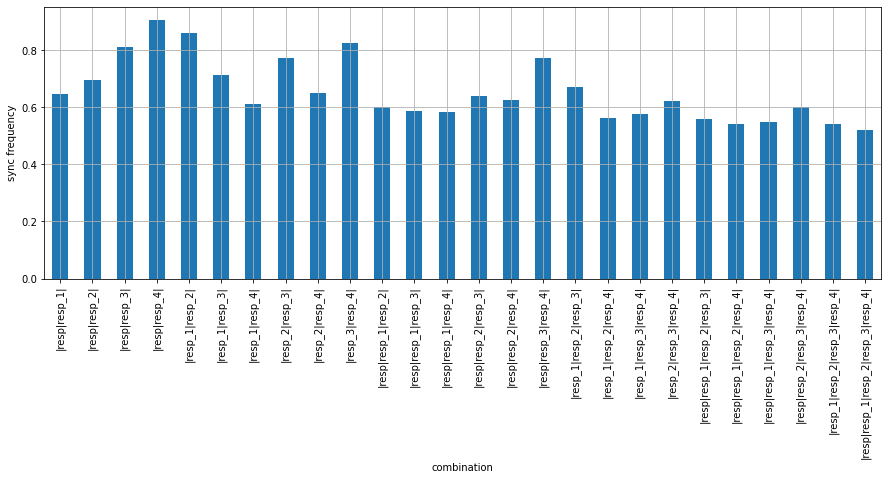

In [4]:
sync_frequency = train[ train.columns[train.columns.str.contains('\|resp')] ].sum() / len(train)
sync_frequency.plot.bar(grid=True, figsize=(15, 5), ylabel='sync frequency', xlabel='combination')
sync_frequency.sort_values(ascending=False)
# sync means positive together or negative together

## consistency #1: correlation between pairs
Pearson tells about pairs only, not combinations of more than two variables, so can't replace the above barplot. Hence the purpose of this notebook.

In [5]:
# bar plot consistent with our expectation that ```resp``` is highly correlated to ```resp_4```
train[ train.columns[train.columns.str.contains('^resp')] ].corr()

,resp,resp_1,resp_2,resp_3,resp_4
resp,1.000000,0.450288,0.594586,0.814738,0.956227
resp_1,0.450288,1.000000,0.889247,0.677821,0.357481
resp_2,0.594586,0.889247,1.000000,0.824104,0.468847
resp_3,0.814738,0.677821,0.824104,1.000000,0.804603
resp_4,0.956227,0.357481,0.468847,0.804603,1.000000


## consistency #2: pairplot
```pairplot``` shows pairs only, not combinations of more than two variables, so can't replace the above barplot. Hence the purpose of this notebook.

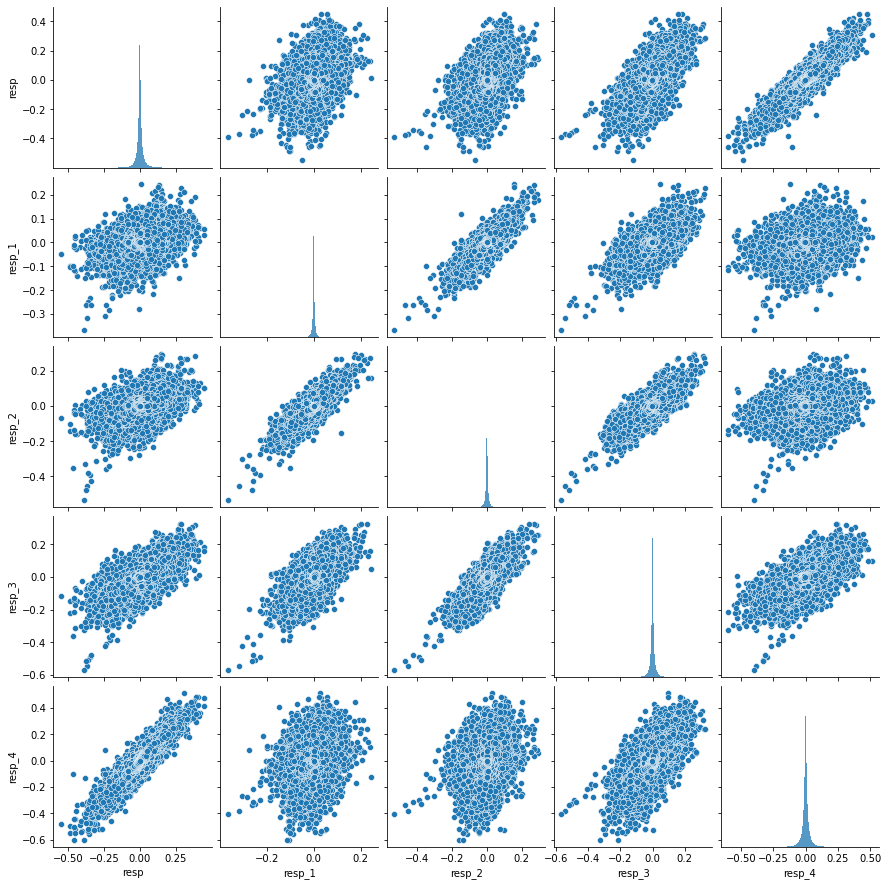

In [6]:
sns.pairplot(train[ train.columns[train.columns.str.contains('^resp')] ])

## sanity check: in case we need to be convinced

In [7]:
# sanity
auto = sync_frequency['|resp_1|resp_2|resp_3|']
manual = (((train['resp_1']>0) & (train['resp_2']>0) & (train['resp_3']>0)) | 
         ((train['resp_1']<0) & (train['resp_2']<0) & (train['resp_3']<0))).sum()/len(train)
np.testing.assert_allclose(auto, manual)
manual, auto

(0.6727485720140495, 0.6727485720140495)

In [8]:
print('toc', datetime.now(timezone('Canada/Pacific')).isoformat(timespec='minutes') )

toc 2021-02-20T19:28-08:00
